In [1]:
#Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
#Load the final dataset
df = pd.read_csv(
    "../data/final/waterborne_disease_risk_dataset.csv",
    keep_default_na=False
)

In [3]:
df.head()

,country,region,year,water_source_type,contaminant_level,ph,turbidity,dissolved_oxygen,nitrate,lead,...,infant_mortality_rate,gdp_per_capita,healthcare_access,urbanization,sanitation_coverage,rainfall,temperature,population_density,total_disease_cases,risk_level
0,Mexico,North,2015,Lake,1.04,6.88,0.15,9.38,10.91,3.03,...,13.77,11855,59.52,85.96,97.36,676,16.48,80,30,Low
1,Brazil,West,2017,Well,2.48,7.26,1.06,6.73,21.71,4.67,...,19.08,10434,80.14,84.78,94.37,1796,23.11,25,70,Medium
2,Indonesia,Central,2022,Pond,3.38,7.58,7.03,4.67,22.55,8.32,...,35.79,4559,54.05,51.23,76.44,1672,24.76,114,241,High
3,Nigeria,East,2016,Well,2.50,6.86,2.40,7.88,16.29,5.01,...,74.65,2293,46.38,58.27,48.95,1015,25.97,241,98,Medium
4,Mexico,South,2005,Well,0.73,6.52,2.24,7.80,8.91,2.00,...,18.73,10765,71.50,91.83,87.58,453,25.09,52,42,Low


In [4]:
#Dataset Overview
print(df.shape)

df.info()

(3000, 26)
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   country                 3000 non-null   str    
 1   region                  3000 non-null   str    
 2   year                    3000 non-null   int64  
 3   water_source_type       3000 non-null   str    
 4   contaminant_level       3000 non-null   float64
 5   ph                      3000 non-null   float64
 6   turbidity               3000 non-null   float64
 7   dissolved_oxygen        3000 non-null   float64
 8   nitrate                 3000 non-null   float64
 9   lead                    3000 non-null   float64
 10  bacteria_count          3000 non-null   int64  
 11  water_treatment_method  3000 non-null   str    
 12  clean_water_access      3000 non-null   float64
 13  diarrheal_cases         3000 non-null   int64  
 14  cholera_cases           3000 non-null   

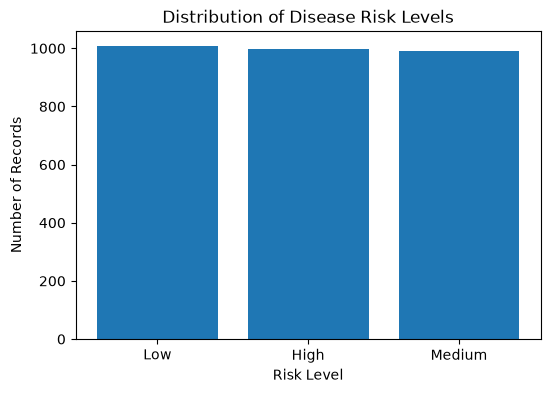

In [5]:
#Distribution of Risk Levels
risk_counts = df["risk_level"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    risk_counts.index,
    risk_counts.values
)

plt.title("Distribution of Disease Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Records")

plt.show()

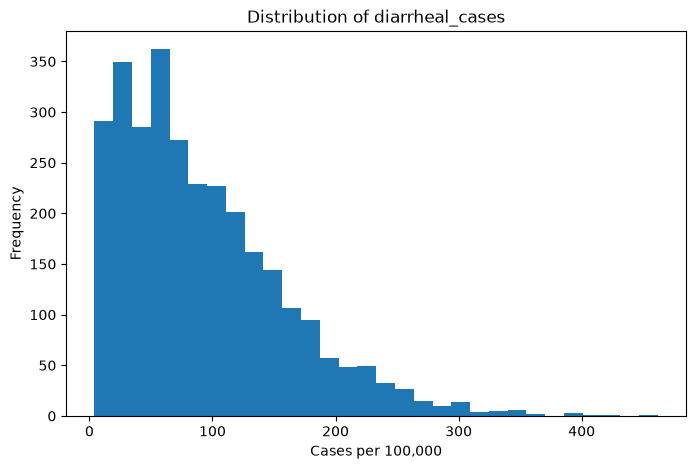

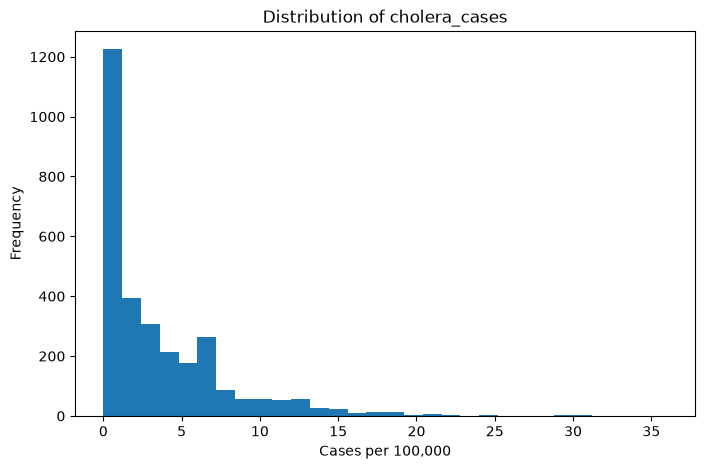

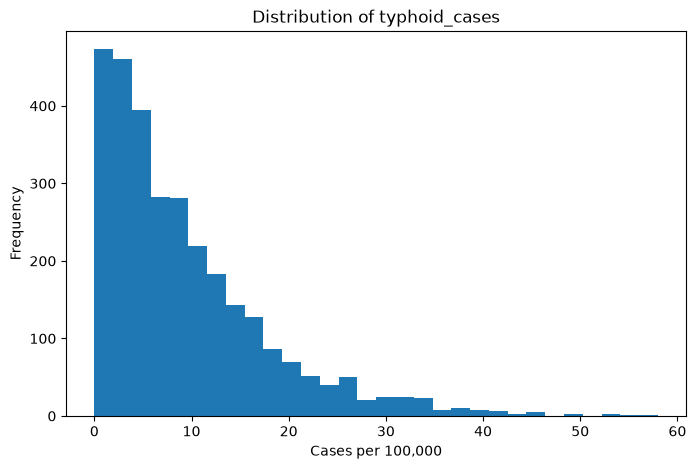

In [21]:
#Disease Distribution
diseases = [
    "diarrheal_cases",
    "cholera_cases",
    "typhoid_cases"
]

for disease in diseases:

    plt.figure(figsize=(8,5))

    plt.hist(df[disease], bins=30)

    plt.title(f"Distribution of {disease}")

    plt.xlabel("Cases per 100,000")

    plt.ylabel("Frequency")

    plt.show()

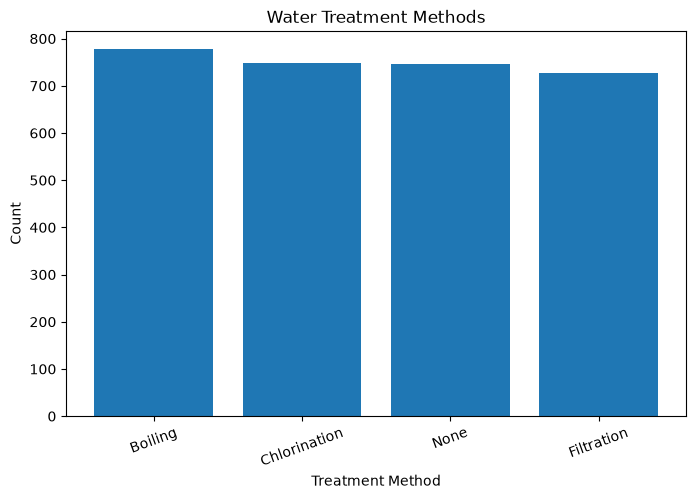

In [23]:
#Water Treatment Method
treatment = df["water_treatment_method"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(treatment.index, treatment.values)

plt.title("Water Treatment Methods")

plt.xlabel("Treatment Method")

plt.ylabel("Count")

plt.xticks(rotation=20)

plt.show()

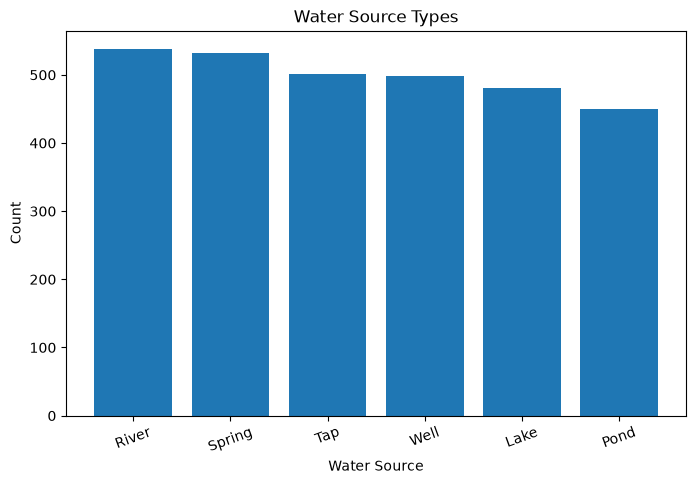

In [22]:
#Water Source Type
source = df["water_source_type"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(source.index, source.values)

plt.title("Water Source Types")

plt.xlabel("Water Source")

plt.ylabel("Count")

plt.xticks(rotation=20)

plt.show()

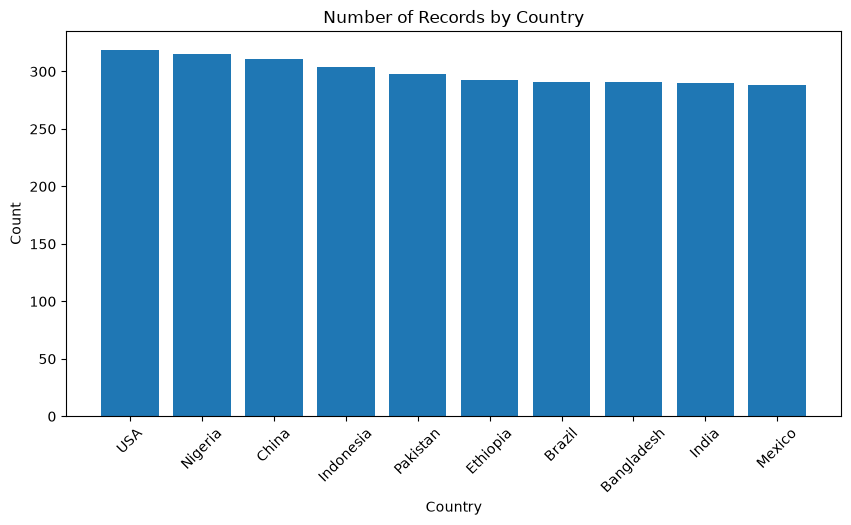

In [24]:
#Country Distribution
country = df["country"].value_counts()

plt.figure(figsize=(10,5))

plt.bar(country.index, country.values)

plt.title("Number of Records by Country")

plt.xlabel("Country")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [10]:
numeric_df = df.select_dtypes(
    include=["int64","float64"]
)

In [11]:
#Correlation Matrix
correlation = numeric_df.corr()

correlation

,year,contaminant_level,ph,turbidity,dissolved_oxygen,nitrate,lead,bacteria_count,clean_water_access,diarrheal_cases,...,typhoid_cases,infant_mortality_rate,gdp_per_capita,healthcare_access,urbanization,sanitation_coverage,rainfall,temperature,population_density,total_disease_cases
year,1.000000,-0.011919,0.016667,-0.018621,-0.000564,0.002178,-0.021538,-0.013204,0.035425,-0.024159,...,-0.020423,0.010807,0.019887,0.027983,0.036826,0.016450,0.012997,0.002676,0.000623,-0.024439
contaminant_level,-0.011919,1.000000,-0.169038,0.851994,-0.758188,0.775151,0.788955,0.808887,-0.260712,0.848285,...,0.782978,0.278914,-0.300297,-0.279109,-0.228500,-0.254920,0.280914,0.343625,0.260753,0.854013
ph,0.016667,-0.169038,1.000000,-0.158891,0.126977,-0.136429,-0.146937,-0.145653,0.030429,-0.157658,...,-0.137682,-0.046856,0.030436,0.036883,0.016682,0.046888,-0.049470,-0.058996,-0.028880,-0.156916
turbidity,-0.018621,0.851994,-0.158891,1.000000,-0.730723,0.667663,0.726874,0.878826,-0.205590,0.863203,...,0.820440,0.244034,-0.211136,-0.215244,-0.174818,-0.203844,0.179153,0.258802,0.193092,0.873816
dissolved_oxygen,-0.000564,-0.758188,0.126977,-0.730723,1.000000,-0.670040,-0.653184,-0.686546,0.290761,-0.728985,...,-0.675950,-0.349880,0.399222,0.340633,0.226120,0.282625,-0.266923,-0.541575,-0.268122,-0.734242
nitrate,0.002178,0.775151,-0.136429,0.667663,-0.670040,1.000000,0.588665,0.629613,-0.248693,0.708679,...,0.631377,0.200658,-0.388323,-0.272363,-0.280718,-0.221566,0.632853,0.485617,0.515630,0.710598
lead,-0.021538,0.788955,-0.146937,0.726874,-0.653184,0.588665,1.000000,0.688613,-0.418195,0.789544,...,0.728063,0.428135,-0.345923,-0.414799,-0.329926,-0.415670,0.139200,0.331013,0.200114,0.794961
bacteria_count,-0.013204,0.808887,-0.145653,0.878826,-0.686546,0.629613,0.688613,1.000000,-0.186274,0.832008,...,0.801779,0.223784,-0.193713,-0.195917,-0.152518,-0.186516,0.172343,0.240193,0.170629,0.844243
clean_water_access,0.035425,-0.260712,0.030429,-0.205590,0.290761,-0.248693,-0.418195,-0.186274,1.000000,-0.449820,...,-0.415513,-0.887210,0.601648,0.870938,0.801047,0.909893,0.039120,-0.408314,-0.259750,-0.452529
diarrheal_cases,-0.024159,0.848285,-0.157658,0.863203,-0.728985,0.708679,0.789544,0.832008,-0.449820,1.000000,...,0.857417,0.453425,-0.357357,-0.436905,-0.365778,-0.437702,0.200894,0.358402,0.268284,0.997244


C:\Users\Kevin.Moses\AppData\Local\Temp\ipykernel_7392\1809040865.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[feature], vert=False)


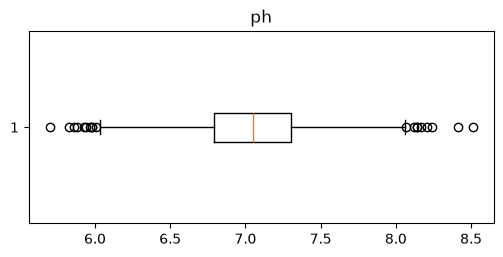

C:\Users\Kevin.Moses\AppData\Local\Temp\ipykernel_7392\1809040865.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[feature], vert=False)


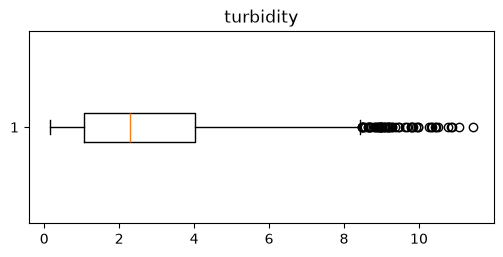

C:\Users\Kevin.Moses\AppData\Local\Temp\ipykernel_7392\1809040865.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[feature], vert=False)


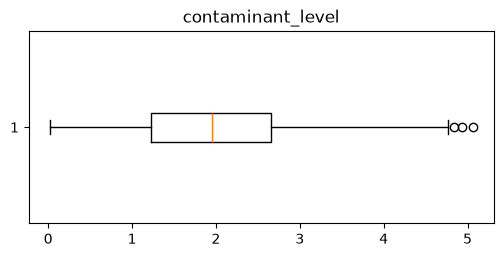

C:\Users\Kevin.Moses\AppData\Local\Temp\ipykernel_7392\1809040865.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[feature], vert=False)


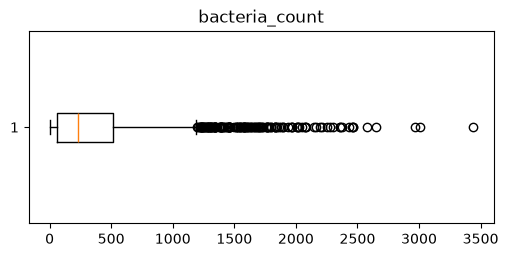

C:\Users\Kevin.Moses\AppData\Local\Temp\ipykernel_7392\1809040865.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[feature], vert=False)


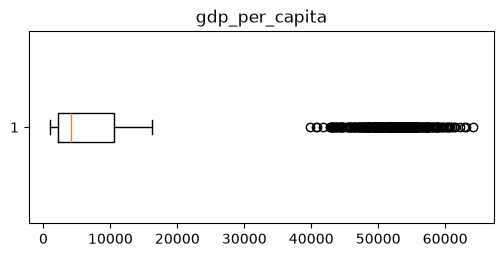

In [12]:
#Boxplots for outliers
features = [
    "ph",
    "turbidity",
    "contaminant_level",
    "bacteria_count",
    "gdp_per_capita"
]

for feature in features:

    plt.figure(figsize=(6,2.5))

    plt.boxplot(df[feature], vert=False)

    plt.title(feature)

    plt.show()

In [13]:
df.describe()

,year,contaminant_level,ph,turbidity,dissolved_oxygen,nitrate,lead,bacteria_count,clean_water_access,diarrheal_cases,...,typhoid_cases,infant_mortality_rate,gdp_per_capita,healthcare_access,urbanization,sanitation_coverage,rainfall,temperature,population_density,total_disease_cases
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,2012.012667,1.972287,7.043397,2.743283,7.335710,16.950683,4.799220,361.840000,78.223633,92.469333,...,9.113333,37.251260,10251.307000,63.115777,57.502410,72.905567,1276.001000,21.839833,281.549667,105.145333
std,7.229287,0.961239,0.380709,2.140164,1.054605,5.792659,2.616363,416.813769,14.295192,66.967355,...,8.621171,23.368128,15032.513018,14.495548,21.102243,17.197683,666.430851,5.370643,358.300120,77.912676
min,2000.000000,0.020000,5.700000,0.150000,3.970000,2.880000,0.050000,2.000000,40.970000,4.000000,...,0.000000,2.000000,958.000000,28.450000,15.000000,28.130000,301.000000,7.040000,12.000000,4.000000
25%,2006.000000,1.230000,6.790000,1.060000,6.610000,12.737500,2.837500,59.000000,67.877500,41.000000,...,3.000000,16.815000,2217.000000,51.897500,39.647500,63.887500,805.000000,17.877500,64.000000,45.000000
50%,2012.000000,1.950000,7.050000,2.290000,7.350000,16.400000,4.690000,232.000000,78.285000,77.000000,...,7.000000,32.940000,4128.500000,62.455000,57.160000,75.130000,1044.000000,23.200000,159.000000,87.000000
75%,2018.000000,2.660000,7.300000,4.010000,8.082500,20.742500,6.652500,512.000000,91.140000,130.000000,...,13.000000,62.345000,10543.000000,73.762500,78.890000,86.762500,1709.000000,26.000000,305.000000,148.000000
max,2024.000000,5.060000,8.510000,11.430000,10.260000,36.670000,14.200000,3435.000000,99.700000,462.000000,...,58.000000,85.990000,64097.000000,99.000000,96.000000,99.500000,3600.000000,32.660000,1700.000000,539.000000


In [14]:
#Rounds all numbers to 2 decimal places
correlation.round(2)

,year,contaminant_level,ph,turbidity,dissolved_oxygen,nitrate,lead,bacteria_count,clean_water_access,diarrheal_cases,...,typhoid_cases,infant_mortality_rate,gdp_per_capita,healthcare_access,urbanization,sanitation_coverage,rainfall,temperature,population_density,total_disease_cases
year,1.00,-0.01,0.02,-0.02,-0.00,0.00,-0.02,-0.01,0.04,-0.02,...,-0.02,0.01,0.02,0.03,0.04,0.02,0.01,0.00,0.00,-0.02
contaminant_level,-0.01,1.00,-0.17,0.85,-0.76,0.78,0.79,0.81,-0.26,0.85,...,0.78,0.28,-0.30,-0.28,-0.23,-0.25,0.28,0.34,0.26,0.85
ph,0.02,-0.17,1.00,-0.16,0.13,-0.14,-0.15,-0.15,0.03,-0.16,...,-0.14,-0.05,0.03,0.04,0.02,0.05,-0.05,-0.06,-0.03,-0.16
turbidity,-0.02,0.85,-0.16,1.00,-0.73,0.67,0.73,0.88,-0.21,0.86,...,0.82,0.24,-0.21,-0.22,-0.17,-0.20,0.18,0.26,0.19,0.87
dissolved_oxygen,-0.00,-0.76,0.13,-0.73,1.00,-0.67,-0.65,-0.69,0.29,-0.73,...,-0.68,-0.35,0.40,0.34,0.23,0.28,-0.27,-0.54,-0.27,-0.73
nitrate,0.00,0.78,-0.14,0.67,-0.67,1.00,0.59,0.63,-0.25,0.71,...,0.63,0.20,-0.39,-0.27,-0.28,-0.22,0.63,0.49,0.52,0.71
lead,-0.02,0.79,-0.15,0.73,-0.65,0.59,1.00,0.69,-0.42,0.79,...,0.73,0.43,-0.35,-0.41,-0.33,-0.42,0.14,0.33,0.20,0.79
bacteria_count,-0.01,0.81,-0.15,0.88,-0.69,0.63,0.69,1.00,-0.19,0.83,...,0.80,0.22,-0.19,-0.20,-0.15,-0.19,0.17,0.24,0.17,0.84
clean_water_access,0.04,-0.26,0.03,-0.21,0.29,-0.25,-0.42,-0.19,1.00,-0.45,...,-0.42,-0.89,0.60,0.87,0.80,0.91,0.04,-0.41,-0.26,-0.45
diarrheal_cases,-0.02,0.85,-0.16,0.86,-0.73,0.71,0.79,0.83,-0.45,1.00,...,0.86,0.45,-0.36,-0.44,-0.37,-0.44,0.20,0.36,0.27,1.00


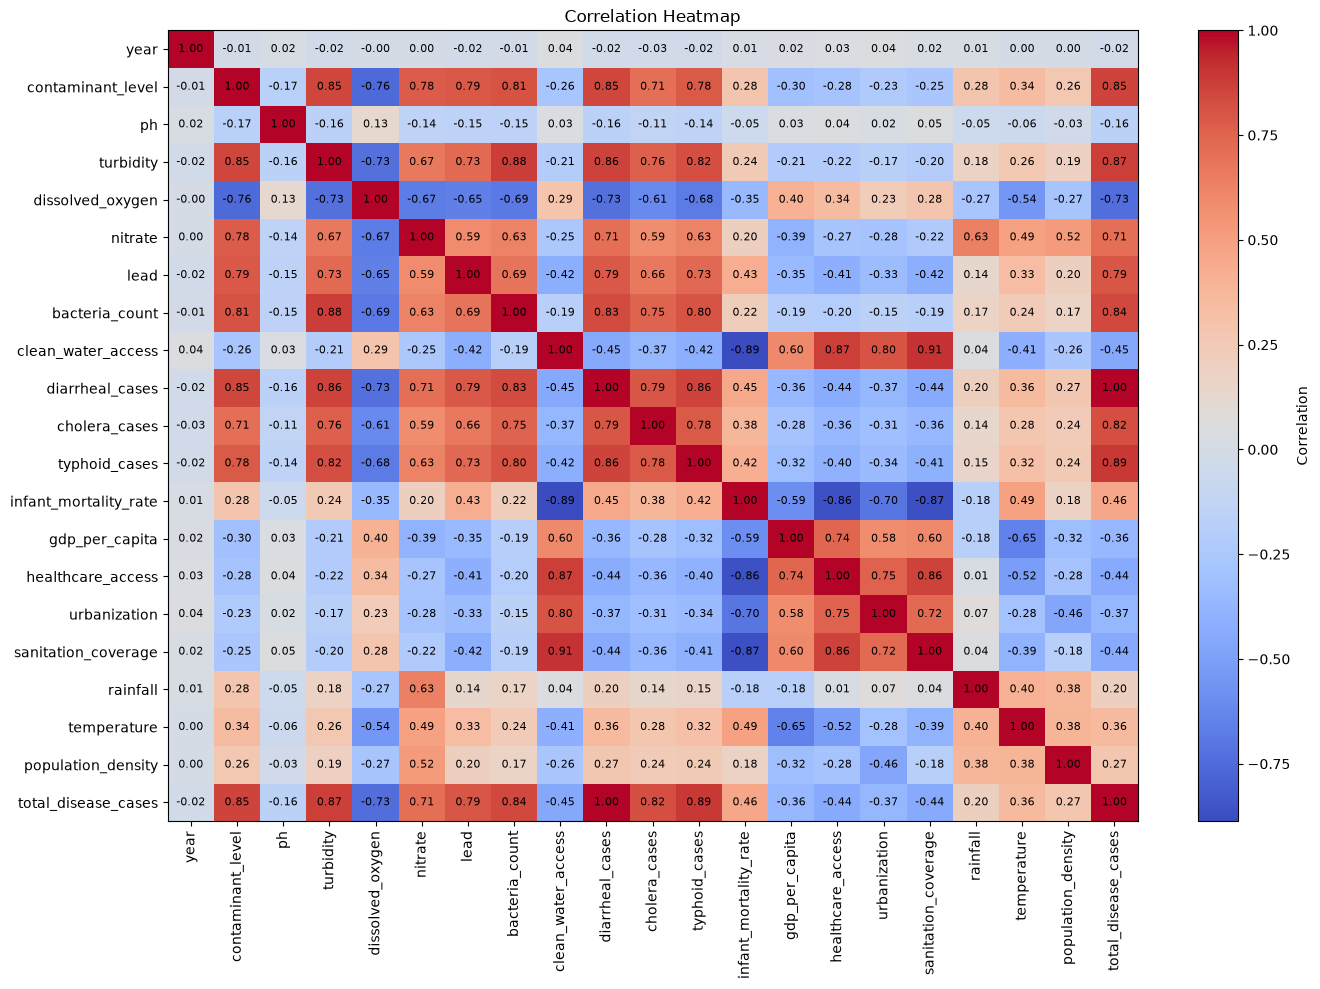

In [15]:
#Correlation Heatmap
correlation = df.select_dtypes(include=["int64","float64"]).corr()

plt.figure(figsize=(14,10))

plt.imshow(correlation, cmap="coolwarm", aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(range(len(correlation.columns)),correlation.columns,rotation=90)

plt.yticks(range(len(correlation.columns)),correlation.columns)

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):plt.text(j, i, f"{correlation.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontsize=8)
        
plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

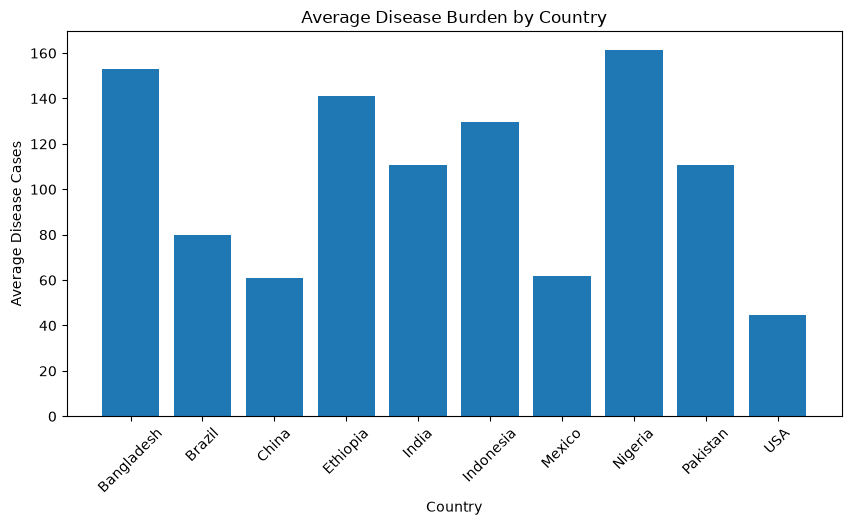

In [16]:
#Average Disease Burden by Country
country_cases = df.groupby("country")["total_disease_cases"].mean()

plt.figure(figsize=(10,5))

plt.bar(country_cases.index, country_cases.values)

plt.title("Average Disease Burden by Country")

plt.xlabel("Country")

plt.ylabel("Average Disease Cases")

plt.xticks(rotation=45)

plt.show()

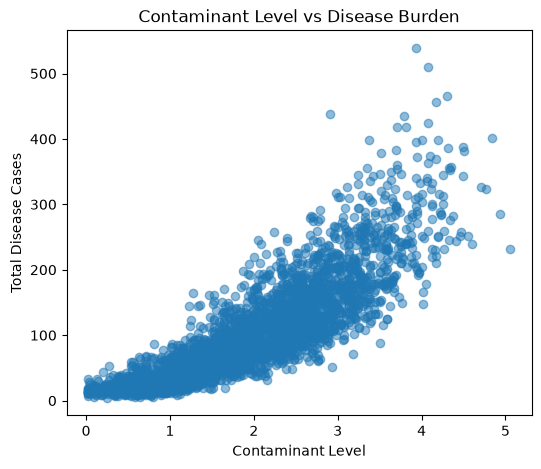

In [17]:
#Scatter plot for Contaminant Level vs Disease Burden
plt.figure(figsize=(6,5))

plt.scatter(
    df["contaminant_level"],
    df["total_disease_cases"],
    alpha=0.5
)

plt.title("Contaminant Level vs Disease Burden")

plt.xlabel("Contaminant Level")

plt.ylabel("Total Disease Cases")

plt.show()

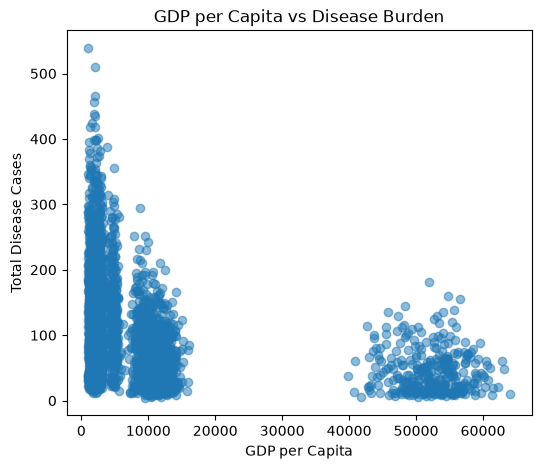

In [18]:
#Scatter plot for GDP vs Disease Burden
plt.figure(figsize=(6,5))

plt.scatter(
    df["gdp_per_capita"],
    df["total_disease_cases"],
    alpha=0.5
)

plt.title("GDP per Capita vs Disease Burden")

plt.xlabel("GDP per Capita")

plt.ylabel("Total Disease Cases")

plt.show()

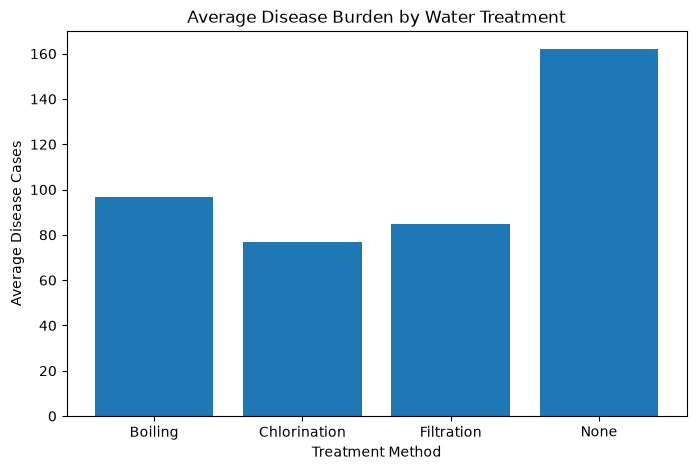

In [19]:
#Average Disease Burden by Water Treatment
treatment = df.groupby("water_treatment_method")["total_disease_cases"].mean()

plt.figure(figsize=(8,5))

plt.bar(treatment.index, treatment.values)

plt.title("Average Disease Burden by Water Treatment")

plt.xlabel("Treatment Method")

plt.ylabel("Average Disease Cases")

plt.show()

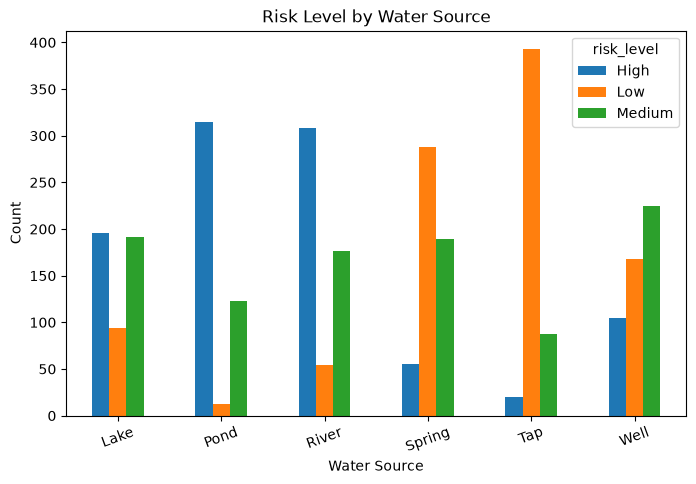

In [20]:
#Risk Level by Water Source
risk_source = pd.crosstab(
    df["water_source_type"],
    df["risk_level"]
)

risk_source.plot(kind="bar", figsize=(8,5))

plt.title("Risk Level by Water Source")

plt.xlabel("Water Source")

plt.ylabel("Count")

plt.xticks(rotation=20)

plt.show()

In [ ]:
#Identify outliers using the IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower) |
        (data[column] > upper)
    ]

    print(f"{column}")
    print(f"Number of Outliers: {len(outliers)}")
    print("-" * 40)

    return outliers

In [26]:
numerical_columns = [
    "contaminant_level",
    "ph",
    "turbidity",
    "dissolved_oxygen",
    "nitrate",
    "lead",
    "bacteria_count",
    "clean_water_access",
    "gdp_per_capita",
    "healthcare_access",
    "urbanization",
    "sanitation_coverage",
    "rainfall",
    "temperature",
    "population_density"
]

for column in numerical_columns:
    detect_outliers_iqr(df, column)

contaminant_level
Number of Outliers: 3
----------------------------------------
ph
Number of Outliers: 19
----------------------------------------
turbidity
Number of Outliers: 59
----------------------------------------
dissolved_oxygen
Number of Outliers: 3
----------------------------------------
nitrate
Number of Outliers: 16
----------------------------------------
lead
Number of Outliers: 5
----------------------------------------
bacteria_count
Number of Outliers: 144
----------------------------------------
clean_water_access
Number of Outliers: 0
----------------------------------------
gdp_per_capita
Number of Outliers: 319
----------------------------------------
healthcare_access
Number of Outliers: 0
----------------------------------------
urbanization
Number of Outliers: 0
----------------------------------------
sanitation_coverage
Number of Outliers: 5
----------------------------------------
rainfall
Number of Outliers: 34
----------------------------------------
tem

In [ ]:
#Checking the skewness
df[numerical_columns].skew().sort_values()

temperature           -0.567434
sanitation_coverage   -0.531248
clean_water_access    -0.312615
dissolved_oxygen      -0.048520
ph                    -0.018385
urbanization           0.019780
healthcare_access      0.145336
contaminant_level      0.205159
lead                   0.239535
nitrate                0.380598
turbidity              0.983205
rainfall               0.999952
bacteria_count         2.081623
gdp_per_capita         2.301491
population_density     2.330970
dtype: float64

In [28]:
print(df["ph"].min())
print(df["ph"].max())

5.7
8.51
